<a href="https://colab.research.google.com/github/kamnakurre005-source/food_recommender/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("daily_food_nutrition_dataset.csv", on_bad_lines='skip')

In [ ]:
df.head()

,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml)
0,Scrambled Eggs (2 large),Protein/Dairy,180,12.0,2.0,14.0,0.0,1.0,180,370,Breakfast,250
1,Whole Wheat Toast (1 slice),Grain,80,4.0,14.0,1.0,2.0,2.0,140,0,Breakfast,0
2,Coffee (black),Beverage,5,0.3,0.0,0.1,0.0,0.0,5,0,Breakfast,0
3,Banana,Fruit,105,1.3,27.0,0.4,3.1,14.0,1,0,Breakfast,0
4,Grilled Chicken Salad,Meal/Protein,350,30.0,10.0,20.0,5.0,4.0,400,80,Lunch,500


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 645 entries, 0 to 644
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Food_Item          645 non-null    object 
 1   Category           645 non-null    object 
 2   Calories (kcal)    645 non-null    int64  
 3   Protein (g)        645 non-null    float64
 4   Carbohydrates (g)  645 non-null    float64
 5   Fat (g)            645 non-null    float64
 6   Fiber (g)          645 non-null    float64
 7   Sugars (g)         645 non-null    float64
 8   Sodium (mg)        645 non-null    int64  
 9   Cholesterol (mg)   645 non-null    int64  
 10  Meal_Type          645 non-null    object 
 11  Water_Intake (ml)  645 non-null    int64  
dtypes: float64(5), int64(4), object(3)
memory usage: 60.6+ KB


In [ ]:
df.describe()

,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Water_Intake (ml)
count,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000
mean,146.294574,6.300620,15.435194,6.469612,1.702481,5.294264,246.331783,20.482171,68.700775
std,139.984360,8.782683,16.349230,8.142916,2.121275,8.537343,308.472431,43.560072,137.077115
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,0.500000,1.300000,0.200000,0.000000,0.400000,5.000000,0.000000,0.000000
50%,105.000000,2.700000,9.200000,3.000000,1.000000,2.000000,120.000000,0.000000,0.000000
75%,200.000000,7.000000,27.000000,10.000000,3.000000,6.000000,350.000000,25.000000,0.000000
max,680.000000,45.000000,70.000000,40.000000,14.000000,60.000000,1580.000000,450.000000,500.000000


In [ ]:
df.isnull().sum()

,0
Food_Item,0
Category,0
Calories (kcal),0
Protein (g),0
Carbohydrates (g),0
Fat (g),0
Fiber (g),0
Sugars (g),0
Sodium (mg),0
Cholesterol (mg),0


In [ ]:
df.duplicated().sum()

np.int64(54)

In [ ]:
df.shape

(645, 12)

In [ ]:
df.columns

Index(['Food_Item', 'Category', 'Calories (kcal)', 'Protein (g)',
       'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)',
       'Sodium (mg)', 'Cholesterol (mg)', 'Meal_Type', 'Water_Intake (ml)'],
      dtype='object')

In [ ]:
df.tail()

,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml)
640,Pickled Cucumber (1/4 cup),Vegetable,10,0.5,2.0,0.0,1.0,1.0,300,0,Dinner,0
641,Fattoush Salad (1.5 cups),Meal/Vegetarian,250,5.0,25.0,15.0,6.0,5.0,500,0,Lunch,0
642,Fried Pita (1/2 pita in salad),Grain,80,2.0,12.0,3.0,1.0,0.5,150,0,Lunch,0
643,Sumac (1/2 tsp dressing),Condiment,5,0.1,1.0,0.2,0.5,0.0,1,0,Lunch,0
644,Pomegranate Molasses (1 tsp),Condiment,15,0.0,4.0,0.0,0.0,4.0,0,0,Lunch,0


<Axes: xlabel='Category'>

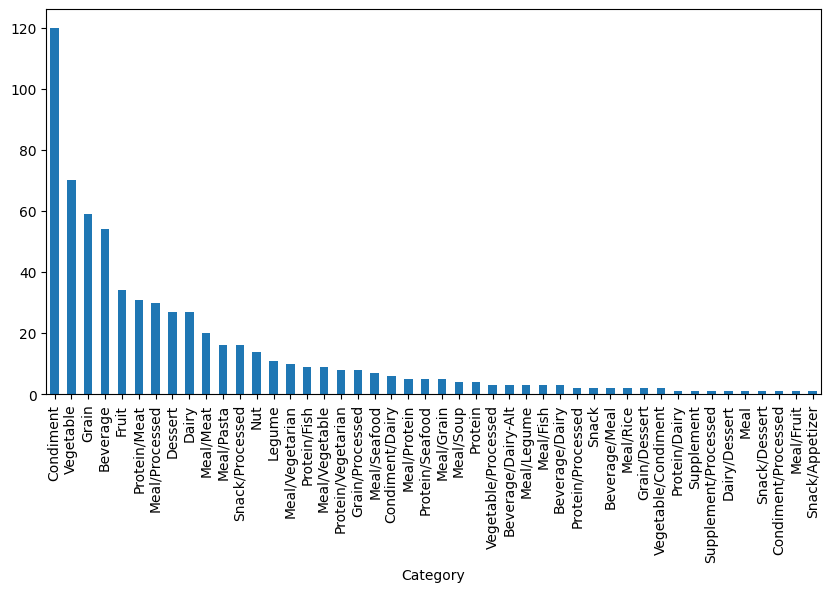

In [ ]:

df['Category'].value_counts().plot(kind='bar', figsize=(10,5))

<Axes: xlabel='Meal_Type'>

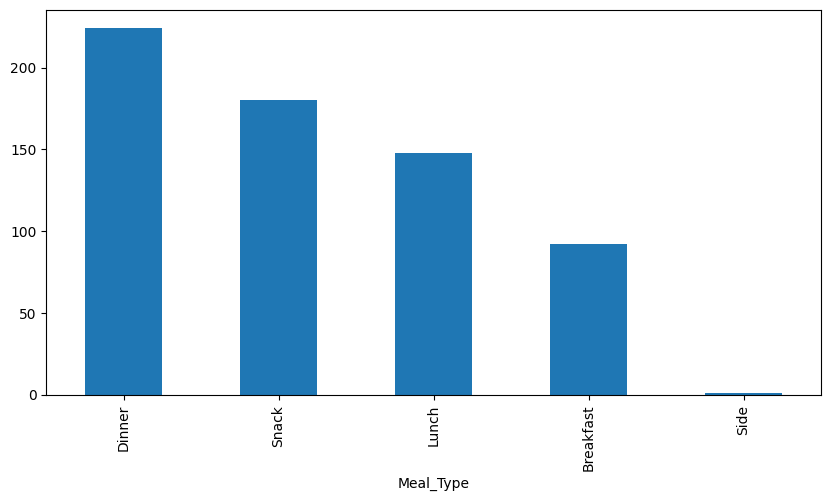

In [ ]:
df['Meal_Type'].value_counts().plot(kind='bar', figsize=(10,5))

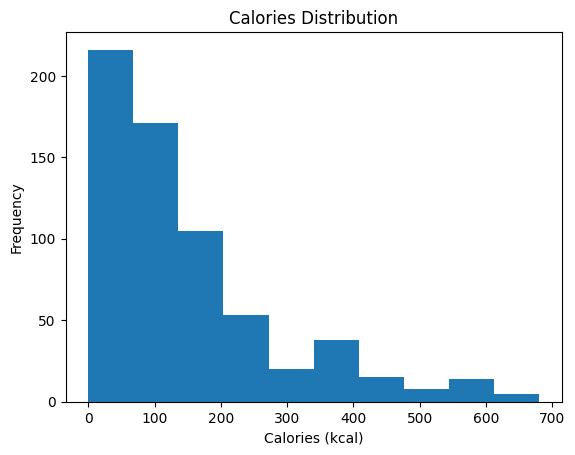

In [ ]:
plt.hist(df['Calories (kcal)'], bins=10)

plt.title('Calories Distribution')
plt.xlabel('Calories (kcal)')
plt.ylabel('Frequency')
plt.show()

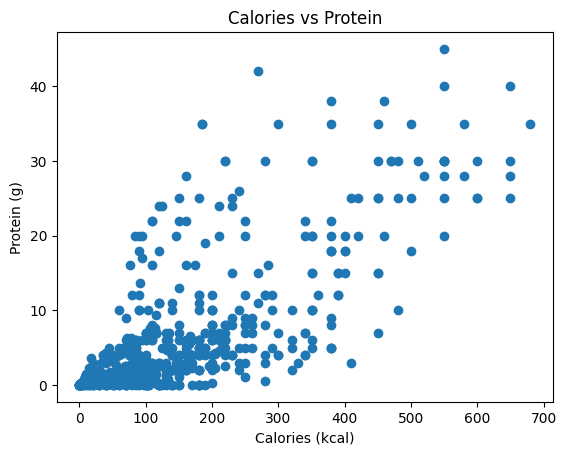

In [ ]:
plt.scatter((df['Calories (kcal)']),df['Protein (g)'])

plt.title('Calories vs Protein')
plt.xlabel('Calories (kcal)')
plt.ylabel('Protein (g)')
plt.show()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity


numerical_df = df.select_dtypes(include=['number'])

similarity_scores = cosine_similarity(numerical_df)
similarity_scores[1]

array([0.47657206, 1.        , 0.96086451, 0.50578563, 0.7082045 ,
       0.51039488, 0.47310669, 0.55124703, 0.90849897, 0.4884332 ,
       0.27972134, 0.51529345, 0.50162323, 0.86735268, 0.99795272,
       0.95471364, 0.99561096, 0.36823837, 0.99486982, 0.92472629,
       0.5098213 , 0.91949663, 0.49441198, 0.89719868, 0.92243205,
       0.65839246, 0.99809743, 0.53311322, 0.58808941, 0.75668521,
       0.94129342, 0.65315791, 0.43567725, 0.9584435 , 0.51518824,
       0.95304783, 0.9214142 , 0.89754034, 0.45764747, 0.50930758,
       0.90282845, 0.90235182, 0.91182098, 0.94195389, 0.44711656,
       0.6497251 , 0.90809221, 0.39482111, 0.98868423, 0.50620896,
       0.96498592, 0.52688118, 0.58787916, 0.540682  , 0.60261325,
       0.99739363, 0.99942236, 0.48275521, 0.99719923, 0.51407179,
       0.28832635, 0.96047021, 0.98491365, 0.96465765, 0.2232945 ,
       0.96015878, 0.99428705, 0.5120813 , 0.29433561, 0.50069668,
       0.73990665, 0.58095634, 0.77917472, 0.18475405, 0.52527

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

features = df[['Calories (kcal)','Protein (g)', 'Carbohydrates (g)', 'Fat (g)','Fiber (g)']]

similarity_scores = cosine_similarity(features)

def recommend_food(keyword):

    matched = df[df['Food_Item'].str.contains(keyword, case=False, na=False)]

    if matched.empty:
        return "No matching food items found."


    idx = matched.index[0]

    similar = list(enumerate(similarity_scores[idx]))
    similar = sorted(similar, key=lambda x: x[1], reverse=True)

    recommendations = []


    for i in matched.index:
        recommendations.append(df.loc[i, ['Food_Item','Calories (kcal)','Protein (g)','Carbohydrates (g)','Fat (g)']])


    for i, score in similar:
        if i not in matched.index:
            recommendations.append(df.loc[i, ['Food_Item','Calories (kcal)','Protein (g)','Carbohydrates (g)','Fat (g)']])
        if len(recommendations) == 10:
            break

    return pd.DataFrame(recommendations)

In [ ]:

recommend_food('soup')

,Food_Item,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g)
19,Lentil Soup (1 can),230,15.0,35.0,3.0
41,Chicken Noodle Soup (1 can),150,7.0,18.0,5.0
76,Tomato Soup (1 can),170,4.0,25.0,6.0
126,Tomato Soup (1 can),170,4.0,25.0,6.0
163,Vegetable Soup (1 can),140,4.0,22.0,4.0
...,...,...,...,...,...
297,Salt (1/4 tsp),0,0.0,0.0,0.0
381,Hot Sauce (1 tsp Tabasco),0,0.0,0.0,0.0
422,Sea Salt (coarse 1/4 tsp),0,0.0,0.0,0.0
513,Club Soda (2 oz),0,0.0,0.0,0.0


In [ ]:
import pickle
pickle.dump(df,open('food_list.pkl','wb'))


In [ ]:
df['Food_Item'].values

array(['Scrambled Eggs (2 large)', 'Whole Wheat Toast (1 slice)',
       'Coffee (black)', 'Banana', 'Grilled Chicken Salad', 'Apple',
       'Salmon (4oz grilled)', 'Quinoa (1 cup cooked)',
       'Steamed Broccoli (1 cup)', 'Greek Yogurt (plain 1 cup)',
       'Oatmeal (1 cup cooked)', 'Blueberries (1/2 cup)',
       'Almonds (1 oz)', 'Turkey Sandwich (on wheat)',
       'Carrot Sticks (1 cup)', 'Spaghetti Bolognese',
       'Side Salad (light dressing)', 'Protein Shake (Whey)',
       'Cereal (Frosted Flakes 1 cup)', 'Lentil Soup (1 can)',
       'White Rice (1 cup cooked)', 'Tofu Stir-fry', 'Orange',
       'Bagel (plain)', 'Cream Cheese (2 tbsp)', 'Tuna Salad (1/2 cup)',
       'Crackers (5 whole wheat)', 'Beef Steak (6oz sirloin)',
       'Baked Potato (medium)', 'Ice Cream (1/2 cup vanilla)',
       'Pizza (1 slice pepperoni)', 'Avocado Toast (1 slice)',
       'Hard-Boiled Egg (1 large)', 'Chicken Wrap (with tortilla)',
       'Grapes (1 cup)', 'Cottage Cheese (1/2 cup)',
     

In [ ]:
pickle.dump(df.to_dict(),open('food_list.pkl','wb'))